  # Capstone Project for Basic Data Science


Data Visualization with Seaborn Using the Penguin Dataset

This project focuses on Exploratory Data Analysis (EDA) a crucial step in data science for 
understanding, visualizing, and preparing data before applying advanced techniques. Using 
pandas for data manipulation and visualization tools like Matplotlib and Seaborn, we will explore 
key patterns, detect anomalies, and handle missing values in the Palmer Penguins Dataset.
The dataset provides biological and physical measurements of three penguin species (Adélie, 
Chinstrap, and Gentoo) from the Palmer Archipelago in Antarctica. By applying various data 
preprocessing techniques, such as handling missing values and visualizing distributions, we aim 
to uncover species differences, identify trends, and ensure the dataset is ready for further 
analysis.
The Palmer Penguins dataset contains measurements of different penguin species, including 
their bill length, bill depth, flipper length, body mass, and sex, collected from three species 
across three islands in Antarctica.

In [15]:
#Importing The Neccessary Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

In [17]:
#Importing The penguins Datsaset
df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [19]:
#The Top 5 records of penguin dataset
#The dimensionality of the dataset
print(df.head())
print(df.shape)
#print(df.dtypes())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
(344, 7)


In [21]:
#Displaying the dimensionality 0f the dataset
#print(df.dtypes())
df.shape

(344, 7)

In [23]:
#The datatypes of the attributes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [25]:
#Checking Column Data Types with df.dtypes
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [27]:
#Describing the dataset extensively
df.describe()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [29]:
#Displaying the number of null values in the dataset and the total count of it
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [31]:
#Identifing the rows having null values and removing them
penguins_cleaned = df.dropna()
print(penguins_cleaned.shape)

(333, 7)


In [33]:
#checking the size of dataset after cleaning and comparing with the size before cleaning
print("Before cleaning:",df.shape)
print("After cleaning:", penguins_cleaned.shape)


Before cleaning: (344, 7)
After cleaning: (333, 7)


In [35]:
#Checking the count of male and female penguins
penguins_cleaned['sex'].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

In [37]:
#Finding out the count of species 
penguins_cleaned['species'].value_counts()


species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

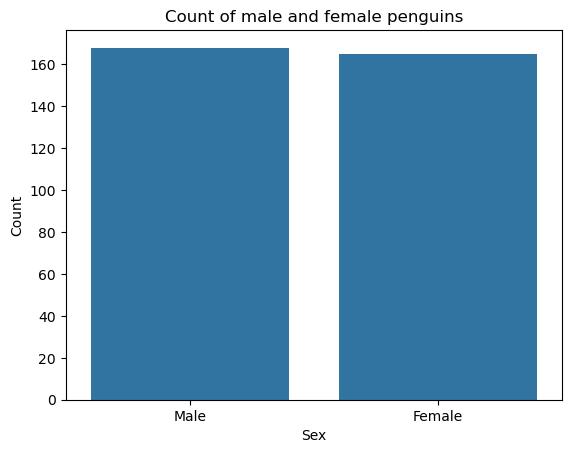

In [39]:
#Using a countplot graph to display the number of male and female penguins
#plot title "Count of male and female penguins"
#xlabel and ylabel 
sns.countplot( x="sex",data=penguins_cleaned)
plt.title("Count of male and female penguins")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

This shows how male and female penguins are distributed within each species. If a bar is taller 
for a gender, that species has more of that gender.

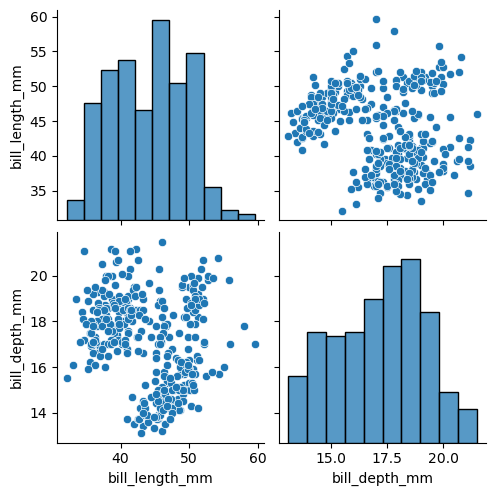

''

In [65]:
#Displaying the bill_length_mm and bill_depth_mm For all the penguins using pairplot
sns.pairplot(penguins_cleaned[['bill_length_mm', 'bill_depth_mm']]) 

plt.show() 

Bill Length and Bill Depth showing different variations across species

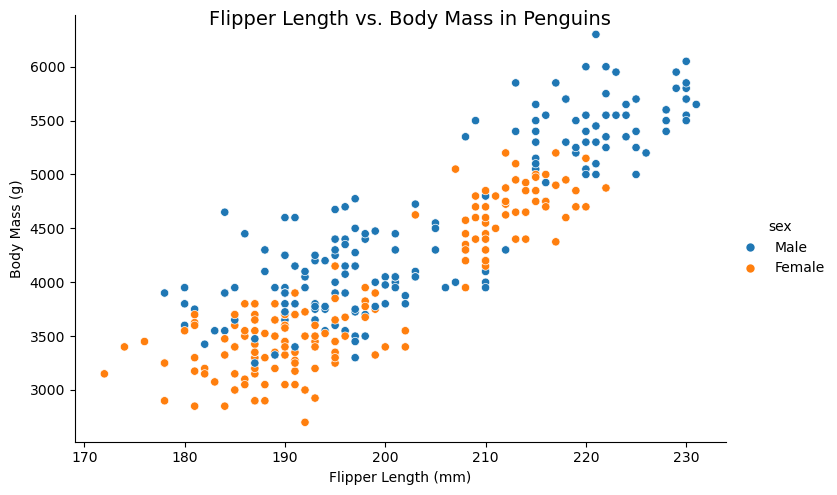

In [48]:
#Visualization displaying the flipper_length_mm and body_mass_g for the penguin dataset.
import seaborn as sns
sns.relplot (
    data=penguins_cleaned,
    x="flipper_length_mm", y="body_mass_g", hue = "sex"
)

plot = sns.relplot(
    data=penguins_cleaned,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="sex",
    aspect=1.5 
)
plot.set_axis_labels("Flipper Length (mm)", "Body Mass (g)")
plot.fig.suptitle("Flipper Length vs. Body Mass in Penguins", fontsize=14)

plt.show()

Flipper length and body mass showing a positive correlation (longer flippers → higher body 
mass).

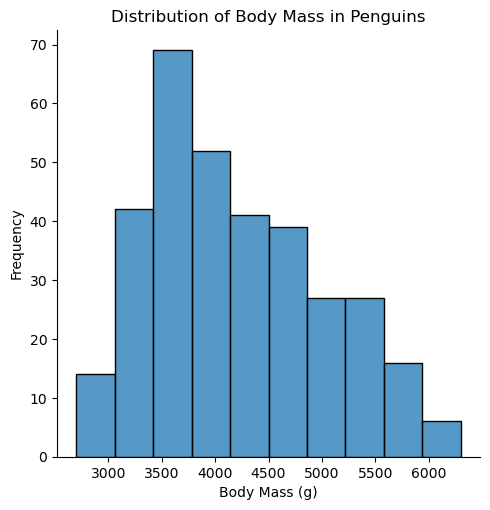

In [50]:
#Histogram plot for body_mass_g with bins = 10
sns.displot(penguins_cleaned["body_mass_g"], kde=False, bins=10)

# title and labels
plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")
plt.title("Distribution of Body Mass in Penguins")

# Display the plot
plt.show()


A histogram shows how frequently different body mass values appear. The shape of the 
histogram tells us whether the data is normally distributed or skewed. If the distribution has a 
long tail, outliers may be present. Outliers exist in body_mass_g

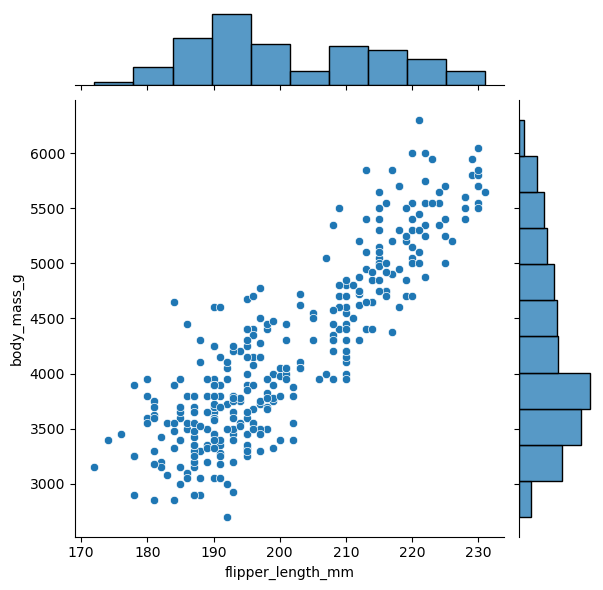

In [43]:
#Scatter joint plot for flipper length vs. body mass
sns.jointplot(
    x='flipper_length_mm',
    y='body_mass_g',
    data=penguins_cleaned,
    kind='scatter'  # Default is scatter
)

# Show the plot
plt.show()


Longer flippers_length_mm generally mean heavier penguins

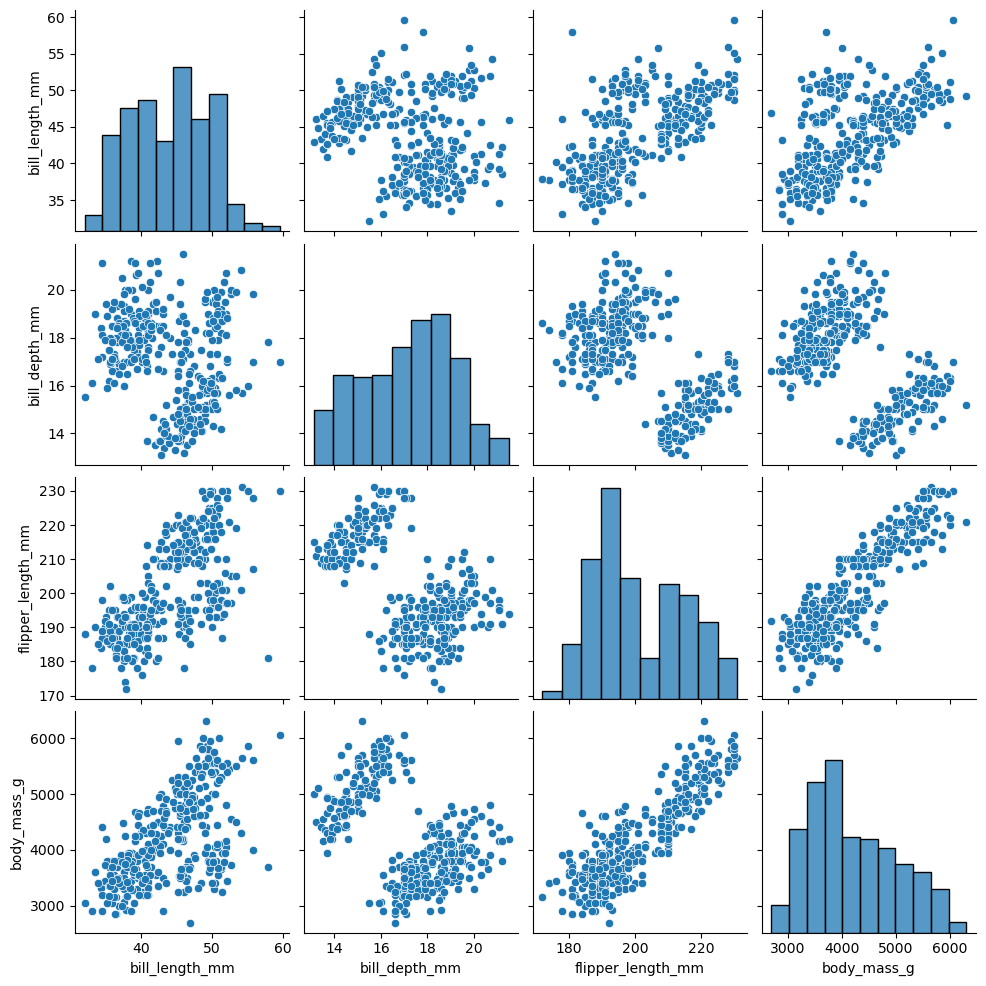

In [52]:
#Using a pairwise plot to display all the numerical values of the dataset penguins_cleaned
sns.pairplot(penguins_cleaned)
plt.show()

Interpretation of the Pairwise Plot
 Diagonal Plots (KDE or Histograms) Shows the distribution of individual numerical variables. 
which Helps to detect if a variable is normally distributed or skewed.
 Off-Diagonal Scatter Plots Showing relationships between numerical variables. this helps to 
detect correlations (e.g., "flipper_length_mm" vs. "body_mass_g"). where points form a clear 
upward or downward trend, the variables are correlated.

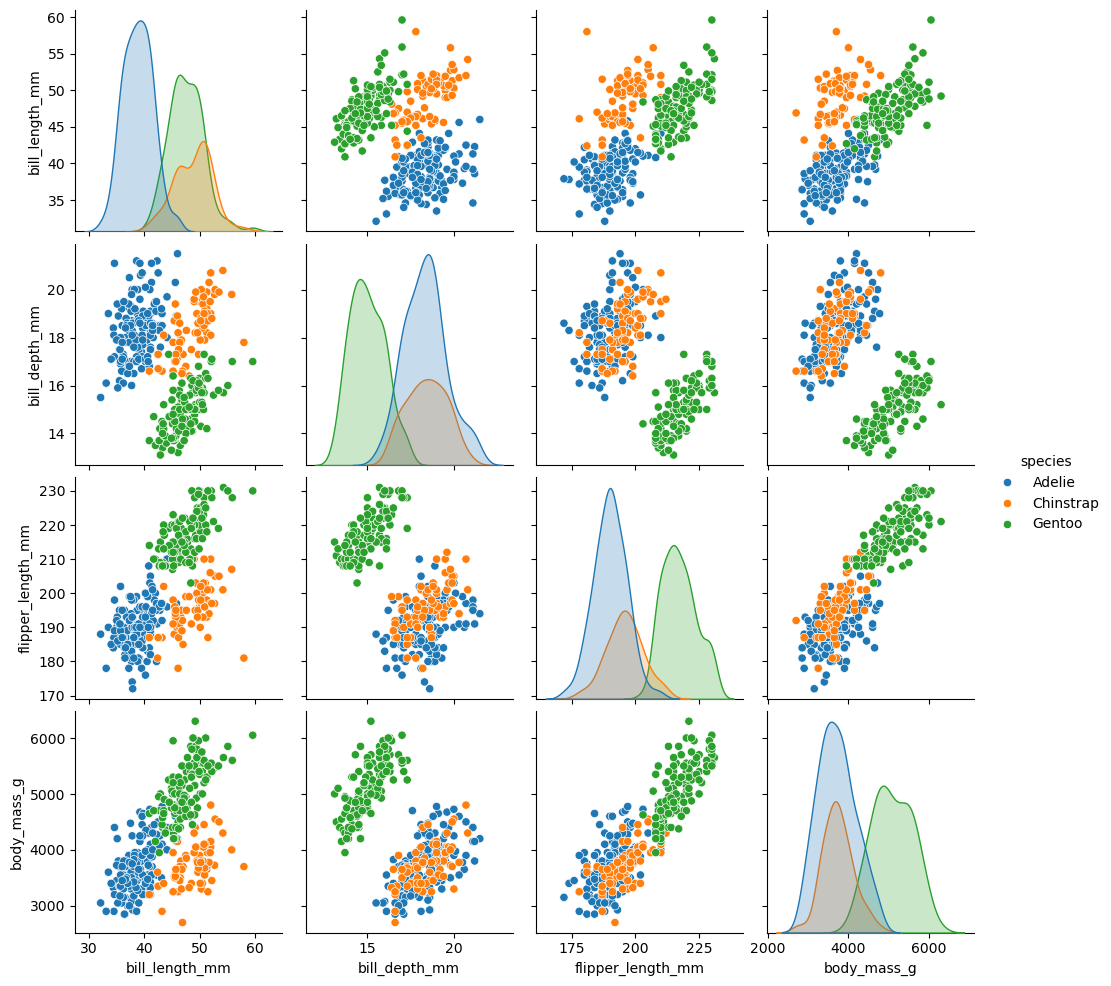

In [56]:
#Checking if there exists any outliers based on the boxplot based on numerical values  of penguins_cleaned dataset
sns.boxplot(y='body_mass_g', data= penguins_cleaned )

sns.pairplot(penguins_cleaned, hue="species")

plt.show()

Boxplot visually displaying the distribution of a numerical variable helps detect outliers. 
Outliers exist in body_mass_g , which is visible as 
points beyond the whiskers in the boxplot,points above or below the 
whiskers, they are outliers in the body mass distribution of Some species e.g Gentoo penguins 
tend to have higher body mass, which might appear as outliers in a general boxplot.

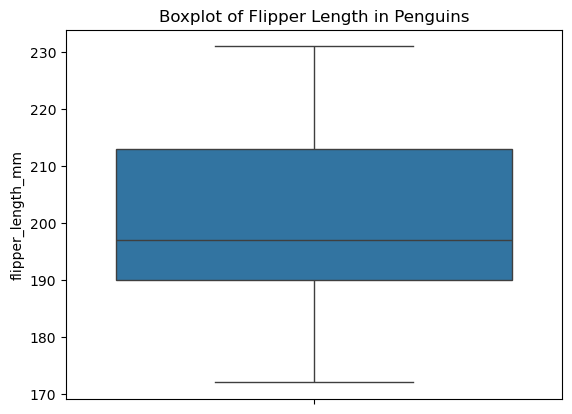

In [70]:
#Boxplot for flipper length
sns.boxplot(y="flipper_length_mm", data=penguins_cleaned)
plt.title("Boxplot of Flipper Length in Penguins")

plt.show()


symmetry is below the median in a boxplot, indicating that the distribution of data is 
skewed to the left (negativly skewed). The left whisker will typically be longer, and the right 
whisker will be shorter. This suggests that most of the data points are clustered toward the 
higher range, with a few lower values that pull the data to the left.This suggests that most 
penguins have longer flippers. A few penguins have much shorter flippers, pulling the 
distribution to the left, creating a negative skew (left skew)

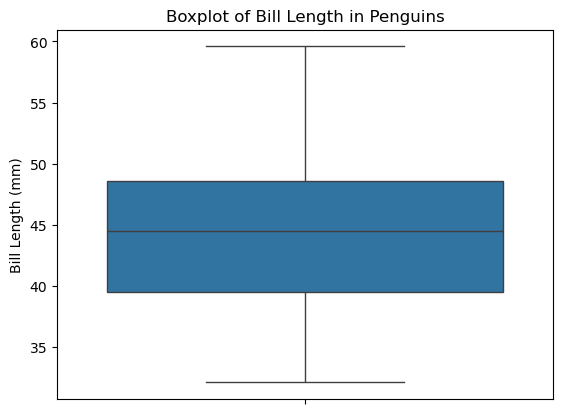

In [84]:
#Boxplot for bill_length_mm
sns.boxplot(y='bill_length_mm', data=penguins_cleaned)

#title and labels
plt.title("Boxplot of Bill Length in Penguins")
plt.ylabel("Bill Length (mm)")

#Show the plot
plt.show()


This indicates that the data is skewed right (positively skewed). The right whisker will typically 
be longer, and the left whisker will be shorter. meaning there are some high outliers or extreme 
values. This suggests that most of the data points are clustered toward the lower range, with a 
few higher values that pull the data to the right. For bill_length_mm , it indicates that most 
penguins have longer bills, but there are a few with very short bills, creating the negative skew

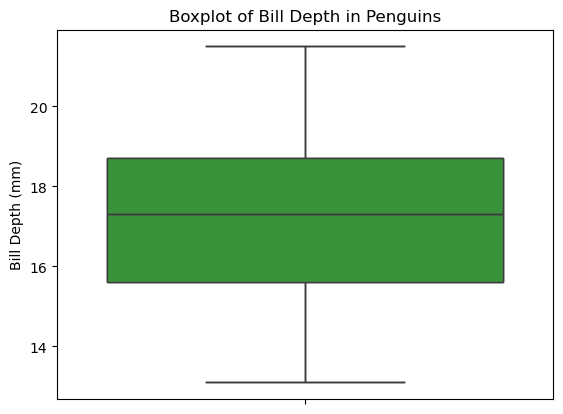

In [90]:
#Boxplot for bill_depth_mm
sns.boxplot(y='bill_depth_mm', data=penguins_cleaned)

#title and labels
plt.title("Boxplot of Bill Depth in Penguins")
plt.ylabel("Bill Depth (mm)")

#Show the plot
plt.show()


Skewed Distribution when the median is off-center, This suggests that most penguins have 
deeper , thicker bills. A few penguins have very shallow thin bills, pulling the distribution to the 
left. The lower whisker will be longer, indicating more variation in lower values. The upper part 
of the box is shorter, meaning bill depth values are concentrated at higher values

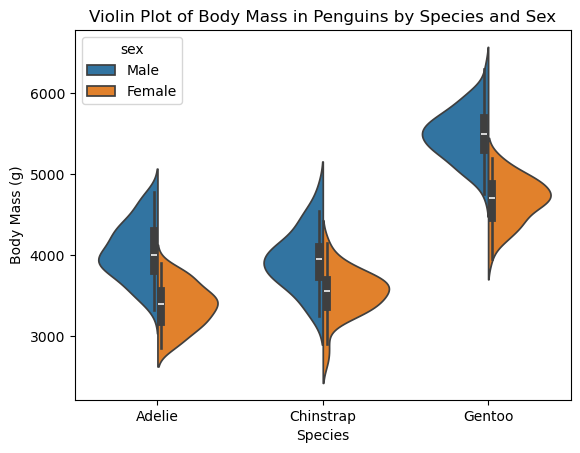

In [98]:
#violin plot displaying  body_mass_g by species and sex
sns.violinplot(x='species', y='body_mass_g', data=penguins_cleaned, hue='sex', split=True)

#Add title and labels
plt.title("Violin Plot of Body Mass in Penguins by Species and Sex")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")

#Show the plot
plt.show()


Violin Plot for Body Mass by Species and Sex shows that Adelie, Chinstrap, Gentoo have different 
body mass distributions. Gentoo penguins tend to have the highest body mass on average. 
Adelie penguins generally have the lowest body mass compared to the other species.
Males usually have higher body mass:
The male penguins tend to be heavier than females across all species. Their distribution is 
generally shifted higher on the y-axis.
 Females usually lower body mass,
Female penguins have a lower median body mass. The violin for females is often narrower at 
higher values, showing that fewer females have high body mass.
 Gentoo penguins are the heaviest among the three species, while Adelie penguins are the 
lightest. Males consistently weigh more than females within each species. The violin plot reveals 
distribution differences and highlights density variations in body mass across species and sex.

# Conclusion

In this capstone project, we explored the Palmer Penguin dataset using Seaborn for data visualization. Through various plots such as histograms, box plots, pair plots, and heatmaps, we uncovered meaningful patterns and relationships between features like species, body measurements, and sex. The visualizations helped to highlight differences among penguin species and revealed correlations between key physical attributes.
This project demonstrated the power of exploratory data analysis (EDA) and how effective visual tools can lead to deeper insights into a dataset. It also reinforced the importance of data types, data cleaning, and clear visual storytelling in the data science process.

Project Presentation By Agatha Ebelechukwu Onwudiwe